# COGS 108 - Financial News Sentiment as a Predictor of NVIDIA Stock Movement

## Permissions

* [  ] YES - make available
* [x] NO - keep private

## Link to video
*(Add your publicly viewable video link here)*

## Overview

In this project, we investigated which type of financial news source's sentiment best predicts NVIDIA's stock price movement during May–June 2023. We clustered ~1,000 NVDA-related articles from six publishers into three groups (Opinion/Retail, Quant/Analyst, and RealTime News), scored each with VADER sentiment analysis, and merged daily average sentiment scores with NVDA's actual stock returns for statistical testing. We found that RealTime News sources (MarketWatch, Benzinga, and Investing.com) had the only statistically significant same-day correlation with returns (r = 0.33, p = 0.036), while next-day prediction was weak across all clusters, suggesting news sentiment is priced into NVIDIA rapidly within the same trading day.

## Authors

- Siya Kamboj: Conceptualization, Data Curation, Methodology, Writing - original draft
- Vivian Zhu: Background research, Experimental investigation, Writing - original draft
- Kaitlyn Tam: Background research, Methodology, Writing - original draft
- Ludwig Von Schoenfeldt: Conceptualization, Experimental investigation, Software, Writing – review & editing
- Phillip Schiffman: Experimental investigation, Visualization, Writing - review & editing

## Research Question

Our project analyzes which financial news type’s sentiment is the strongest predictor of stock price movement for NVIDIA in May & June of 2023. We will use a dataset containing news headlines from multiple sources, each labeled with a sentiment polarity score and publication date, along with NVIDIA’s daily stock returns. For each source, we will calculate daily average sentiment and match it with same-day and next-day stock returns. The main variables include sentiment polarity, daily percent return, and price volatility. We will use correlation analysis and multiple linear regression to compare how well each source’s sentiment predicts stock behavior.

## Background and Prior Work

As new information enters the market and shapes expectations, stock prices often move in response to news. Since the COVID-19 period, markets have become faster, with news spreading almost instantly across different platforms. This highlights how financial news has become an important factor in influencing stock price movements. Focusing on the influence of financial news sentiment in stock price movements, our research question is: “Which financial news source’s sentiment is the strongest predictor of stock price movement for NVIDIA in the post-COVID period?”

During the early stages of the pandemic, global stock markets experienced declines, and investor expectations were changing frequently. The unusual news events changed up the usual market patterns, making prices more unpredictable.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) This suggests that after COVID, markets respond to news more quickly, which is why looking at the sentiment of financial news can be useful for understanding stock price movements.

The relationship between news sentiment and stock price movements has been studied on a large-scale in financial economics. A study by Tetlock demonstrates that media sentiment can influence stock prices by analyzing daily Wall Street Journal content. He found that highly negative news often leads to price drops, and unusual sentiment drives higher trading, showing that news can predict the market.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)  This supports the idea that different sources’ sentiment may have measurable effects on prices, which we aim to analyze for NVIDIA.

A recent study by Gao et al. finds that investor attention, measured through sentiment from multiple news providers, can affect stock returns. <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) For example when attention rises, prices often move in predictable ways, showing that variations in news attention can influence short-term market behavior. Additionally Cristescu et al. analyze how sentiment polarity from financial news titles and descriptions correlates with stock price changes for major tech companies, showing measurable connections and illustrating ways to analyze sentiment versus price. <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

Looking at more recent studies, they compare sentiment across multiple news sources to see which best predicts stock movements. For example, one study uses machine learning to weigh the impact of different sources, showing that some news outlets are more useful than others for forecasting. Building on these findings, our project will analyze the pre-existing sentiment scores from multiple financial news sources to determine which is most predictive of NVIDIA’s stock price, without developing new sentiment models.


1. <a name="cite_note-1"></a> Gormsen, N., & Koijen, R. (2020, March 26). How the Coronavirus Affects Stock Prices and Growth Expectations. The University of Chicago Booth School of Business. https://www.chicagobooth.edu/review/how-coronavirus-affects-stock-prices-and-growth-expectations

2. <a name="cite_note-2"></a> Tetlock, P. C. (2005). Giving Content to Investor Sentiment: The Role of Media in the Stock Market. SSRN Electronic Journal. https://doi.org/10.2139/ssrn.685145

3. <a name="cite_note-3"></a> Gao, R., Cui, S., Xiao, H., Fan, W., Zhang, H., & Wang, Y. (2022). Integrating the sentiments of multiple news providers for stock market index movement prediction: A deep learning approach based on evidential reasoning rule. Information Sciences, 615, 529–556. https://doi.org/10.1016/j.ins.2022.10.029

4. <a name="cite_note-4"></a> Cristescu, M. P., Mara, D. A., Nerișanu, R. A., Culda, L. C., & Maniu, I. (2023). Analyzing the Impact of Financial News Sentiments on Stock Prices—A Wavelet Correlation. Mathematics, 11(23), 4830. https://doi.org/10.3390/math11234830

## Hypothesis


We hypothesize that news sentiment from major, high-credibility financial news sources will be significantly correlated with NVIDIA's short-term stock returns, particularly next-day returns, while sentiment from smaller or less specialized outlets will show weaker or no consistent relationship.

To test "credibility," we grouped the six publishers into clusters based on their style of coverage and audience reach. Widely-followed, fast-turnaround outlets like MarketWatch, Benzinga, and Investing.com represent high-credibility, real-time sources (RealTime_News cluster). While opinion-driven outlets like The Motley Fool and Seeking Alpha represent retail-focused analysis (Opinion_Retail cluster). Finally, Zacks represents quantitative analyst coverage (Quant_Analyst cluster).

We expect this outcome because large financial news organizations are more widely read by institutional and retail investors and tend to report information more quickly and consistently. As a result, their sentiment is more likely to influence market behavior or reflect information that is rapidly incorporated into stock prices. In contrast, smaller or more opinion-driven sources may publish content that is less timely or less impactful on investor decisions, leading to noisier or insignificant relationships with stock returns.

## Data

### Data overview

- Dataset #1
  - Dataset Name: Financial News with Ticker-Level Sentiment

  - Link to the dataset: https://www.kaggle.com/datasets/rdolphin/financial-news-with-ticker-level-sentiment?resource=download

  - Number of observations: The full dataset contains many observations; however, due to free-tier API limits, only 1000 NVIDIA-related articles (May–June 2023) could be downloaded. We also had to exclude a publisher that did not fit the clustering scheme (GlobeNewswire Inc., 18 articles), so the working dataset contains 982 observations.

  - Number of variables: 7 variables (published_utc, publisher, title, description, article_url, source, insights) were given in the dataset, and 5 variables (publisher_cluster, sentiment_model, sentiment_label, sentiment_score, sentiment_detail) were generated by us for preprocessing 

  - Description of the variables most relevant to this project: The most relevant variables for this project are the ones we generated during preprocessing. After listing all unique publisher names in the dataset, we grouped them into three clusters based on the style of coverage. The Motley Fool and Seeking Alpha were classified as Opinion / Retail Analysis, Zacks Investment Research as Quant / Analyst, and MarketWatch, Benzinga, and Investing.com as Real-Time News. This grouping is stored in the publisher_cluster variable and allows us to analyze sentiment by type of source rather than individual publisher to give us more data and robust analysis. We also generated sentiment variables using the VADER model, including sentiment_score (−1 to 1), sentiment_label (positive, neutral, negative), and sentiment_detail. These provide the main signal used to compare with stock price movement in dataset #2. Finally, the original published_utc timestamp is important because it lets us merge the news data with Dataset #2 and group by date.

  - Descriptions of any shortcomings this dataset has with repsect to the project:
    - The free-tier API does not provide ticker-level sentiment insights, so the `insights` field is null for all observations.Hence, sentiment scores were generated using the VADER model, which is not specifically fine-tuned for financial text. This may produce less accurate sentiment estimates compared to finance-specific models which are harder to access on a free tier.  
    - The dataset covers only a two-month period (May–June 2023). Results may therefore not generalize to other time periods especially if there were other real-world factors during that time (ie WHO just announced that COVID was no longer a public health emergency in May 2023).
    - The sample is limited to the first 1000 available articles due to the free tier of the API, which may introduce sampling bias.

- Dataset #2
  - Dataset Name: 
    - Massive Yahoo Finance Dataset
  - Link to the dataset: 
    - https://www.kaggle.com/datasets/iveeaten3223times/massive-yahoo-finance-dataset
  - Number of observations: 
    - ~1+ million daily records (varies by ticker; ~500 companies over ~5 years)
  - Number of variables: 
    - Typically 7 core variables per record: (Date, Open, High, Low, Close, Adjusted Close, Volume)
  - Description of the variables most relevant to this project: 
    - Date – trading day; used to align stock prices with sentiment timestamps
    - Ticker – identifies the company; used for merging with sentiment data
    - Open / High / Low / Close – daily price movement indicators
    - Adjusted Close – price adjusted for splits/dividends; best for return calculations
    - Volume – trading activity; can indicate market reaction intensity
  - Descriptions of any shortcomings this dataset has with repsect to the project:
    - Covers only ~5 years of data, limiting long-term trend analysis.
    - Contains daily frequency data only, making it difficult to study intraday sentiment reactions.
    - Focuses on large-cap companies (~top 500), which may bias results toward highly liquid stocks.
    - Does not include macroeconomic indicators, fundamentals, or market news context — these must be sourced separately.
    - Market holidays and missing trading days require alignment with sentiment timestamps.

Since we have 2 different datasets, we will be joining them on date to see the correlation between overall sentiment for a day and stock changes on that day. For instance, the yfinance dataset has 43 rows for the 43 different trading days, and the first dataset has published_utc as a field for which day/time that every article was published.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.append('./modules')

import get_data

datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1U45CYCUOw1FzCrxRMvfLDeN7yo1mpQhy', 'filename':'stock_sentiment_1000.json'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1nMg2pbuGvVCy2ZMPrEDBf2_DdrqQDUOg', 'filename':'stock_details_5_years.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:01<00:01,  1.96s/it]

Successfully downloaded: stock_sentiment_1000.json


Overall Download Progress: 100%|██████████| 2/2 [00:08<00:00,  4.15s/it]

Successfully downloaded: stock_details_5_years.csv


### NVDA Sentiment Analysis Dataset (May & June 2023)

This dataset consists of financial news articles related to NVIDIA (NVDA) published during May and June 2023. Each observation corresponds to a single article and includes information originally provided by the news API, such as the publication timestamp (`published_utc`), publisher metadata (`publisher` object with name and URLs), article headline (`title`), short summary (`description`), a link to the full article (`article_url`), and the publisher name as a string (`source`). The timestamp is recorded in Coordinated Universal Time (UTC) using ISO-8601 format and indicates when the article was published. These variables describe the content, source, and timing of each news item but do not directly quantify market impact. The dataset also includes an `insights` field that is supposed to contain ticker-level sentiment analysis; however, this field is null for all observations under the free-tier API.

The main concern with this dataset is that it lacks built-in sentiment information under the free tier, which is important to the project’s goal of analyzing how news tone relates to stock price movement. In addition, the dataset is limited to approximately 1000 articles due to API restrictions, which may not represent all NVDA-related news during this period. The coverage is also confined to a two-month window that could coincide with other world events that could have affected the overall stock trends. To address these limitations, we generate our own sentiment scores from the article text using vader model in the code below. Additionally, we don't have that much information from individual publishers, so we grouped publishers by content type and added a field called "publisher_cluster," where Opinion_Retail cluster contains "The Motley Fool" & "Seeking Alpha", Quant_Analyst cluster contains "Zacks Investment Research", and RealTime_News cluster contains "MarketWatch" & "Benzinga" & "Investing.com". 

In [3]:
import json
from collections import Counter
### LOAD THE DATASET
with open("data/00-raw/stock_sentiment_1000.json", "r", encoding="utf-8") as f:
    items = json.load(f)

In [4]:
### STEP 1: CREATE PUBLISHER CLUSTER
CLUSTER_MAP = {
    # Opinion / Retail Analysis
    "The Motley Fool": "Opinion_Retail",
    "Seeking Alpha": "Opinion_Retail",
    # Quant / Analyst
    "Zacks Investment Research": "Quant_Analyst",
    # Real-Time News
    "MarketWatch": "RealTime_News",
    "Benzinga": "RealTime_News",
    "Investing.com": "RealTime_News",
}
filtered_items = []
for item in items:
    src = item.get("source")
    cluster = CLUSTER_MAP.get(src)
    if cluster is not None:   # keeps only chosen groups
        item["publisher_cluster"] = cluster
        filtered_items.append(item)
counts = Counter(x["publisher_cluster"] for x in filtered_items)
for k, v in counts.items():
    print(f"{k}: {v} articles/rows of data")
with open("data/01-interim/stock_sentiment_1000_clustered.json", "w", encoding="utf-8") as f:
    json.dump(filtered_items, f, indent=2, ensure_ascii=False)

Opinion_Retail: 379 articles/rows of data
RealTime_News: 363 articles/rows of data
Quant_Analyst: 240 articles/rows of data


In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def article_text(item: dict) -> str:
    title = (item.get("title") or "").strip()
    desc = (item.get("description") or "").strip()
    # VADER works better with a little context; title alone can be noisy
    if desc:
        return f"{title}. {desc}"
    return title

def vader_sentiment(text: str) -> dict:
    if not text.strip():
        return {
            "sentiment_model": "vader",
            "sentiment_label": "neutral",
            "sentiment_score": 0.0,
            "sentiment_detail": {"pos": 0.0, "neu": 1.0, "neg": 0.0, "compound": 0.0},
        }
    scores = analyzer.polarity_scores(text)
    compound = float(scores["compound"])  # [-1, 1]
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return {
        "sentiment_model": "vader",
        "sentiment_label": label,
        "sentiment_score": compound,
        "sentiment_detail": scores,
    }

with open("data/01-interim/stock_sentiment_1000_clustered.json", "r", encoding="utf-8") as f:
    items = json.load(f)

for item in items:
    text = article_text(item)
    item.update(vader_sentiment(text))

with open("data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json", "w", encoding="utf-8") as f:
    json.dump(items, f, indent=2, ensure_ascii=False)

print(f"Saved {len(items)} items with sentiment to data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json")

Saved 982 items with sentiment to data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json


In [6]:
# SHOW TIDINESS : 1 row per article & 1 column per variable
import json, pandas as pd

IN_PATH = "data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json"

with open(IN_PATH, "r", encoding="utf-8") as f:
    items = json.load(f)

df = pd.DataFrame(items)

df["published_utc"] = pd.to_datetime(df["published_utc"], utc=True)
df["date"] = df["published_utc"].dt.date  # for grouping/joins later

print("Shape (rows, cols):", df.shape)
display(df.head(3))

Shape (rows, cols): (982, 13)


,published_utc,publisher,title,description,article_url,source,insights,publisher_cluster,sentiment_model,sentiment_label,sentiment_score,sentiment_detail,date
0,2023-05-01 09:21:00+00:00,"{'name': 'The Motley Fool', 'homepage_url': 'h...",The Fed Is Forecasting a Recession: 2 Nasdaq 1...,"If an economic downturn materializes, two grow...",https://www.fool.com/investing/2023/05/01/fed-...,The Motley Fool,None,Opinion_Retail,vader,negative,-0.1531,"{'neg': 0.143, 'neu': 0.745, 'pos': 0.112, 'co...",2023-05-01
1,2023-05-01 10:07:45+00:00,"{'name': 'Benzinga', 'homepage_url': 'https://...",S&P Records Second Straight Monthly Gain; Mark...,The S&P 500 closed higher on Friday following ...,https://www.benzinga.com/news/earnings/23/05/3...,Benzinga,None,RealTime_News,vader,positive,0.9578,"{'neg': 0.0, 'neu': 0.801, 'pos': 0.199, 'comp...",2023-05-01
2,2023-05-01 13:40:00+00:00,"{'name': 'Zacks Investment Research', 'homepag...","Stock Market News for May 1, 2023","Wall Street closed higher on Friday, boosted b...",https://www.zacks.com/stock/news/2087416/stock...,Zacks Investment Research,None,Quant_Analyst,vader,positive,0.5574,"{'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'comp...",2023-05-01


,missing_%
insights,100.000000
description,4.989817
published_utc,0.000000
title,0.000000
publisher,0.000000
article_url,0.000000
source,0.000000
publisher_cluster,0.000000
sentiment_model,0.000000
sentiment_label,0.000000


publisher_cluster
Opinion_Retail    0.002639
Quant_Analyst     0.000000
RealTime_News     0.132231
Name: missing_description_rate, dtype: float64

sentiment_score range: -0.9338 0.9961


,published_utc,publisher,title,description,article_url,source,insights,publisher_cluster,sentiment_model,sentiment_label,sentiment_score,sentiment_detail,date


duplicate article_url count: 0


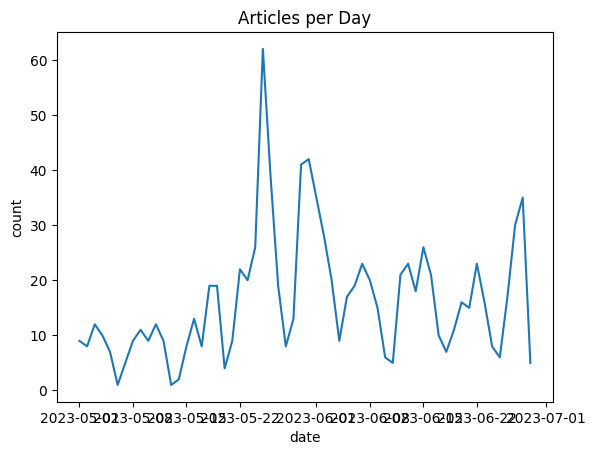

In [7]:
# SHOW MISSINGNESS + SUSPICIOUS ENTRIES/OUTLIERS
import matplotlib.pyplot as plt

# missingness
miss = df.isna().mean().sort_values(ascending=False)
display((miss * 100).rename("missing_%").to_frame())

if df["description"].isna().any():
    display(df["description"].isna().groupby(df["publisher_cluster"]).mean().rename("missing_description_rate"))

# sentiment outliers (VADER should be within [-1, 1])
print("sentiment_score range:", df["sentiment_score"].min(), df["sentiment_score"].max())
display(df[(df["sentiment_score"] < -1) | (df["sentiment_score"] > 1)].head())

# duplicate URLs
print("duplicate article_url count:", df["article_url"].duplicated().sum())

df.groupby("date").size().plot()
plt.title("Articles per Day")
plt.ylabel("count")
plt.show()


In [8]:
# SAVE FINAL CLEANED COPY 
clean = df.copy()
# drop the column insights because it is null, anyways. as shown in the missingness table above.
if "insights" in clean.columns:
    clean = clean.drop(columns=["insights"])

OUT_PATH = "data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json"
clean.to_json(OUT_PATH, orient="records", indent=2, date_format="iso")

clean.groupby("publisher_cluster")["sentiment_score"].agg(["count","mean","std","min","max"])

,count,mean,std,min,max
publisher_cluster,,,,,
Opinion_Retail,379,0.303635,0.423615,-0.9001,0.9382
Quant_Analyst,240,0.303721,0.408807,-0.9119,0.9217
RealTime_News,363,0.320132,0.543510,-0.9338,0.9961


The dataset is tidy (one row per article, one column per variable), contains minimal missing data & the one column (insights) which is fully empty has been removed, shows no duplicate entries or invalid sentiment values, and has reasonable distributions across time and publisher clusters.

### Historical U.S. Stock Price Dataset (Yahoo Finance, 5-Year Window)

This dataset contains daily stock price and trading activity information for large publicly traded U.S. companies over approximately five years. Each record represents one trading day for a specific company and includes price levels and trading volume. The dataset is structured in a tidy format, where each row represents one observation (ticker–date pair) and each column represents a variable.

Important Metrics & Their Meaning
- Date
    - Trading day (YYYY-MM-DD).
    - Used to align stock price movements with news sentiment timestamps.
- Ticker
    - Unique stock symbol identifying a company.
    - Enables merging with sentiment data tied to specific firms.
- Open (USD)
    - Price at the start of the trading day.
    - Reflects overnight market reactions.
- High & Low (USD)
    - Highest and lowest prices reached during the trading day.
    - Used to measure intraday volatility and price range.
- Close (USD)
    - Final trading price for the day.
    - Often used for technical analysis and daily valuation.
- Adjusted Close (USD)
    - Closing price adjusted for stock splits and dividends.
    - Preferred for calculating returns and long-term performance because it reflects true investor value.
- Volume (shares traded)
    - Total number of shares traded that day.
    - High volume often indicates strong investor interest or reaction to news.

Why These Metrics Matter for This Project
- This project aims to predict stock price movement using news sentiment. The dataset enables calculation of:
    - Daily returns (price change)
    - Price direction (up/down) for classification targets
    - Volatility (risk & uncertainty)
    - Volume spikes indicating market reaction intensity
    - Adjusted Close prices will be used to compute returns because they account for corporate actions.


Dataset Limitations & Concerns
- Several limitations should be considered:
    - The dataset includes primarily large-cap companies, which may bias results toward highly liquid, heavily followed stocks.
    - Data is recorded at a daily frequency, preventing analysis of intraday sentiment reactions.
    - The time span (~5 years) limits long-term economic cycle analysis.
    - It does not include macroeconomic variables (interest rates, inflation), which influence market behavior.
    - Market holidays and non-trading days require alignment when merging with sentiment data.
    - Volume spikes may be influenced by algorithmic trading and not purely investor sentiment.
    
Despite these limitations, daily OHLCV data is the standard foundation for financial prediction models and is appropriate for sentiment-based return prediction.

In [ ]:
import pandas as pd

path = "data/00-raw/stock_details_5_years.csv"
stocks = pd.read_csv(path)
# Keep only NVDA rows in stocks dataframe
stocks = stocks[stocks['Company'] == 'NVDA'].copy()

stocks['Company'].value_counts()

Company
NVDA    1258
Name: count, dtype: int64

The dataset is clean, well-structured, and ready for analysis, with each row representing one company’s trading activity on a specific date and all price and volume fields stored in consistent numeric formats. No invalid values or major missing data were observed, and zeros in the dividends and stock split columns correctly indicate no events rather than missing information. To confirm usability, the Date column was converted to datetime format, numeric fields were verified, and the data was sorted by company and date to ensure proper time-series ordering. Minimal preprocessing was required, aside from computing daily returns and creating a price-direction label to serve as the prediction target. Overall, the dataset required only basic validation and feature preparation before being merged with sentiment data.

In [ ]:
# Merge NVDA stock data with article sentiment data by calendar date

stocks_merge = stocks.copy()
news_merge = df.copy()

# Force both sides to UTC first, then drop time to date
stocks_merge["Date"] = pd.to_datetime(stocks_merge["Date"], utc=True, errors="coerce").dt.date
news_merge["date"] = pd.to_datetime(news_merge["published_utc"], utc=True, errors="coerce").dt.date

merged_df = pd.merge(
    stocks_merge,
    news_merge,
    left_on="Date",
    right_on="date",
    how="inner"
)

merged_df = merged_df.drop(columns=["date"])

merged_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,published_utc,...,title,description,article_url,source,insights,publisher_cluster,sentiment_model,sentiment_label,sentiment_score,sentiment_detail
0,2023-05-01,278.348271,290.526001,277.748376,289.046295,57032900,0.0,0.0,NVDA,2023-05-01 09:21:00+00:00,...,The Fed Is Forecasting a Recession: 2 Nasdaq 1...,"If an economic downturn materializes, two grow...",https://www.fool.com/investing/2023/05/01/fed-...,The Motley Fool,None,Opinion_Retail,vader,negative,-0.1531,"{'neg': 0.143, 'neu': 0.745, 'pos': 0.112, 'co..."
1,2023-05-01,278.348271,290.526001,277.748376,289.046295,57032900,0.0,0.0,NVDA,2023-05-01 10:07:45+00:00,...,S&P Records Second Straight Monthly Gain; Mark...,The S&P 500 closed higher on Friday following ...,https://www.benzinga.com/news/earnings/23/05/3...,Benzinga,None,RealTime_News,vader,positive,0.9578,"{'neg': 0.0, 'neu': 0.801, 'pos': 0.199, 'comp..."
2,2023-05-01,278.348271,290.526001,277.748376,289.046295,57032900,0.0,0.0,NVDA,2023-05-01 13:40:00+00:00,...,"Stock Market News for May 1, 2023","Wall Street closed higher on Friday, boosted b...",https://www.zacks.com/stock/news/2087416/stock...,Zacks Investment Research,None,Quant_Analyst,vader,positive,0.5574,"{'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'comp..."
3,2023-05-01,278.348271,290.526001,277.748376,289.046295,57032900,0.0,0.0,NVDA,2023-05-01 17:30:04+00:00,...,Intel: Mega Turnaround Starts Now,With hugely declining revenue/profitability/ca...,https://seekingalpha.com/article/4598556-intel...,Seeking Alpha,None,Opinion_Retail,vader,positive,0.1531,"{'neg': 0.069, 'neu': 0.843, 'pos': 0.087, 'co..."
4,2023-05-01,278.348271,290.526001,277.748376,289.046295,57032900,0.0,0.0,NVDA,2023-05-01 18:16:00+00:00,...,Stocks Rise As Investors Welcome JPMorgan's Pu...,U.S. equities begin the week on a slightly hig...,https://www.benzinga.com/news/earnings/23/05/3...,Benzinga,None,RealTime_News,vader,positive,0.9330,"{'neg': 0.039, 'neu': 0.858, 'pos': 0.103, 'co..."


Now that the stock and sentiment datasets are merged on matching dates, we have a single analysis-ready table that combines market variables with article-level sentiment information. The date alignment step ensures both sources refer to the same time points, which makes downstream comparisons and modeling valid. After removing duplicate date columns, the merged dataset is clean, consistent, and ready for the next steps in EDA and predictive analysis.

## Exploratory Data Analysis

The following exploratory analyses focus directly on the project question: identifying how different types of NVDA-related news sentiment relate to stock movement.

### EDA 1: Which sources have the highest or lowest average sentiment?

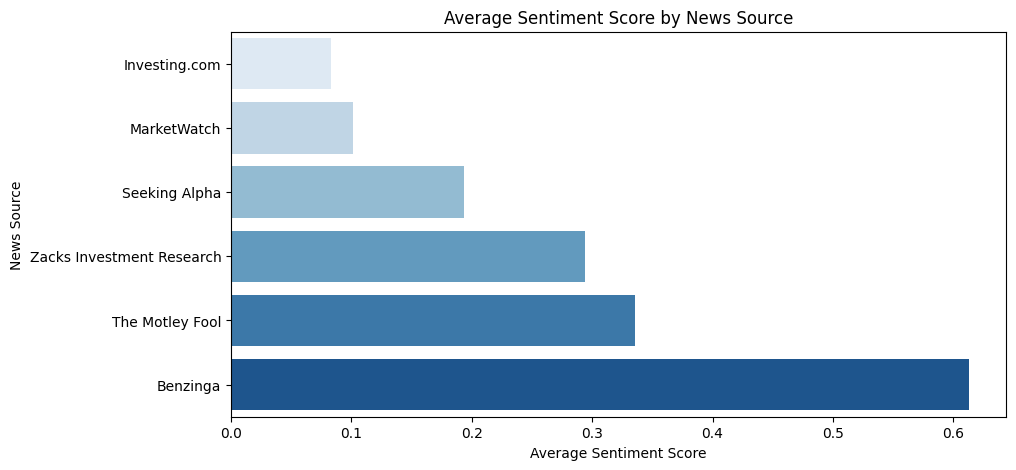

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

merge_cp = merged_df.copy()
merge_cp['sentiment_score'] = merge_cp['sentiment_detail'].apply(lambda x: x['compound'])

avg_sentiment = merge_cp.groupby('source')['sentiment_score'].mean().reset_index()
avg_sentiment = avg_sentiment.sort_values(by='sentiment_score', ascending=True)

plt.figure(figsize=(10,5))
sns.barplot(data=avg_sentiment, x='sentiment_score', y='source', hue='source', palette='Blues')
plt.title('Average Sentiment Score by News Source')
plt.xlabel('Average Sentiment Score')
plt.ylabel('News Source')
plt.show()


**Description:**
This subsection answers the question: which sources are most positive or most negative on average about NVIDIA? The bar chart compares average sentiment scores across publishers. Sources near the top have higher average positive tone, while sources near the bottom are less positive (or relatively more negative). This gives us a baseline before testing which sources are actually linked to stock movement.

**Answer:** Average sentiment clearly differs across publishers, with some sources consistently more positive than others, so source choice matters before we even test sentiment-return relationships.

### EDA 2: Is overall daily sentiment more associated with same-day or next-day return?

Correlation (sentiment vs SAME-DAY return): 0.163
Correlation (sentiment vs NEXT-DAY return): 0.119


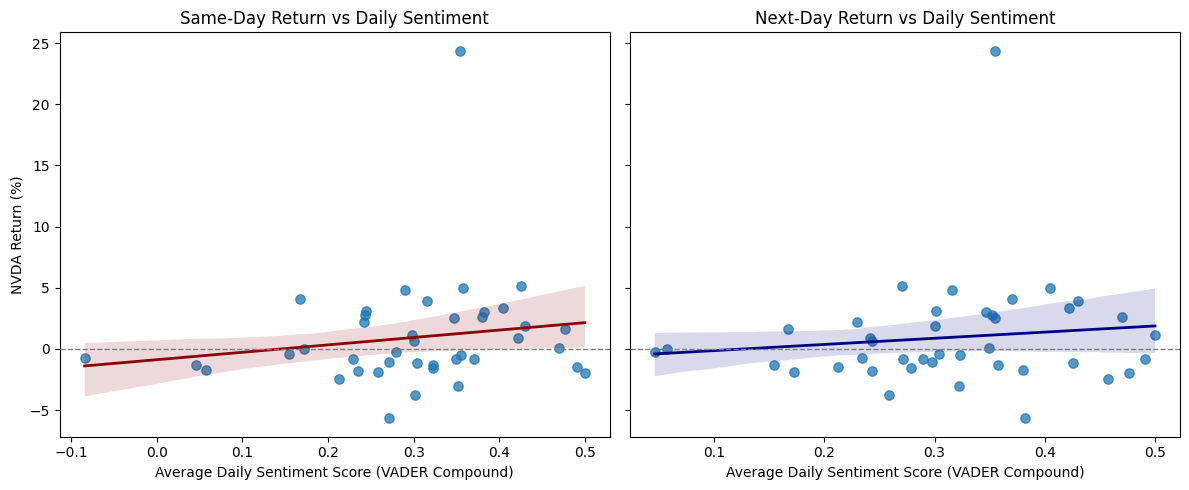

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

relation_cp = merged_df.copy()
relation_cp['sentiment_score'] = relation_cp['sentiment_detail'].apply(
    lambda x: x['compound'] if isinstance(x, dict) and 'compound' in x else np.nan
)

# Aggregate to daily level so each date has one sentiment value
sentiment_daily = (
    relation_cp.groupby('Date', as_index=False)['sentiment_score']
    .mean()
    .sort_values('Date')
)

price_daily = (
    relation_cp[['Date', 'Close']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

daily_eda = price_daily.merge(sentiment_daily, on='Date', how='inner')
daily_eda['daily_return_pct'] = daily_eda['Close'].pct_change() * 100
daily_eda['next_day_return_pct'] = daily_eda['daily_return_pct'].shift(-1)

same_day_df = daily_eda.dropna(subset=['sentiment_score', 'daily_return_pct'])
next_day_df = daily_eda.dropna(subset=['sentiment_score', 'next_day_return_pct'])

corr_same = same_day_df['sentiment_score'].corr(same_day_df['daily_return_pct'])
corr_next = next_day_df['sentiment_score'].corr(next_day_df['next_day_return_pct'])

print(f'Correlation (sentiment vs SAME-DAY return): {corr_same:.3f}')
print(f'Correlation (sentiment vs NEXT-DAY return): {corr_next:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.regplot(
    data=same_day_df,
    x='sentiment_score',
    y='daily_return_pct',
    scatter_kws={'alpha': 0.75, 's': 45},
    line_kws={'color': 'darkred', 'linewidth': 2},
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Same-Day Return vs Daily Sentiment')
axes[0].set_xlabel('Average Daily Sentiment Score (VADER Compound)')
axes[0].set_ylabel('NVDA Return (%)')

sns.regplot(
    data=next_day_df,
    x='sentiment_score',
    y='next_day_return_pct',
    scatter_kws={'alpha': 0.75, 's': 45},
    line_kws={'color': 'navy', 'linewidth': 2},
    ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Next-Day Return vs Daily Sentiment')
axes[1].set_xlabel('Average Daily Sentiment Score (VADER Compound)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Description:**
This subsection compares whether daily sentiment is more associated with same-day returns or next-day returns. We compute both correlations and visualize both relationships side-by-side. If same-day correlation is stronger, it suggests sentiment and price move together quickly within the same trading day. If next-day correlation is stronger, it suggests a lagged predictive effect.

**Answer:** In our results, same-day sentiment association is stronger than next-day association (about 0.163 vs 0.119), so the relationship appears to be more immediate than delayed.

### EDA 3: Which source cluster has the strongest sentiment-return relationship?

Cluster-level sentiment-return correlations:


Target,Next-Day Return,Same-Day Return
Cluster,,
Opinion_Retail,0.229,-0.087
Quant_Analyst,-0.200,-0.236
RealTime_News,0.102,0.333


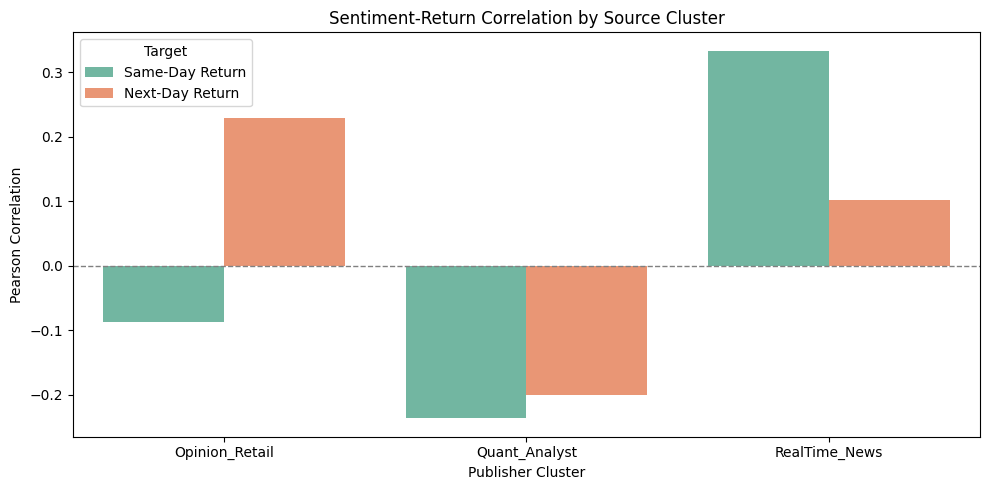

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_cp = merged_df.copy()
cluster_cp['sentiment_score'] = cluster_cp['sentiment_detail'].apply(
    lambda x: x['compound'] if isinstance(x, dict) and 'compound' in x else np.nan
)

# Daily returns
cluster_price = (
    cluster_cp[['Date', 'Close']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)
cluster_price['daily_return_pct'] = cluster_price['Close'].pct_change() * 100
cluster_price['next_day_return_pct'] = cluster_price['daily_return_pct'].shift(-1)

# Daily sentiment by cluster
cluster_daily_sent = (
    cluster_cp.groupby(['Date', 'publisher_cluster'])['sentiment_score']
    .mean()
    .unstack()
    .add_prefix('sentiment_')
    .reset_index()
)

cluster_eda = cluster_price.merge(cluster_daily_sent, on='Date', how='inner')

cluster_cols = [c for c in cluster_eda.columns if c.startswith('sentiment_')]
rows = []
for col in cluster_cols:
    same_tmp = cluster_eda[[col, 'daily_return_pct']].dropna()
    next_tmp = cluster_eda[[col, 'next_day_return_pct']].dropna()

    same_corr = same_tmp[col].corr(same_tmp['daily_return_pct']) if len(same_tmp) > 2 else np.nan
    next_corr = next_tmp[col].corr(next_tmp['next_day_return_pct']) if len(next_tmp) > 2 else np.nan

    cluster_name = col.replace('sentiment_', '')
    rows.append({'Cluster': cluster_name, 'Target': 'Same-Day Return', 'Correlation': same_corr})
    rows.append({'Cluster': cluster_name, 'Target': 'Next-Day Return', 'Correlation': next_corr})

cluster_corr_df = pd.DataFrame(rows)
print('Cluster-level sentiment-return correlations:')
display(cluster_corr_df.pivot(index='Cluster', columns='Target', values='Correlation').round(3))

plt.figure(figsize=(10, 5))
sns.barplot(data=cluster_corr_df, x='Cluster', y='Correlation', hue='Target', palette='Set2')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Sentiment-Return Correlation by Source Cluster')
plt.xlabel('Publisher Cluster')
plt.ylabel('Pearson Correlation')
plt.tight_layout()
plt.show()

**Description:**
This subsection answers which source cluster has the strongest relationship with NVDA returns. We aggregate sentiment by day within each cluster and compute correlations with both same-day and next-day returns. The grouped bar chart makes it easy to compare clusters directly and identify which one has the strongest signal.

**Answer:** RealTime_News has the strongest same-day sentiment-return relationship (about 0.333), while Opinion_Retail is strongest on next-day returns (about 0.229), indicating real-time outlets line up best with same-day price movement.

## Data Analysis & Results

Now that we've explored the data, we can move on to the actual statistical analysis. The goal here is to figure out which publisher cluster's sentiment is the best predictor of NVIDIA's stock price movement during May–June 2023. We use two approaches:

1. Pearson correlation analysis: to measure the linear relationship between each cluster's daily average sentiment and stock returns (same-day and next-day).
2. Multiple linear regression (OLS): to model returns as a function of all three clusters at the same time, so we can see each cluster's individual contribution while controlling for the others.

### Feature Engineering: Daily Analysis DataFrame

Before we can run regression and correlation, we need to aggregate the article-level `merged_df` into one row per trading day. For each day we compute the daily return (%) from closing prices, the next-day return (shifted by one day) so we can test lagged prediction, the average sentiment for each publisher cluster, and the total article count and trading volume.

In [14]:
import numpy as np
import pandas as pd

### DAILY STOCK RETURNS
price = (
    merged_df[['Date', 'Close', 'Volume']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
    .reset_index(drop=True)
)
price['daily_return_pct'] = price['Close'].pct_change() * 100
price['next_day_return_pct'] = price['daily_return_pct'].shift(-1)

### PER-CLUSTER DAILY AVERAGE SENTIMENT
cluster_sent = (
    merged_df
    .groupby(['Date', 'publisher_cluster'])['sentiment_score']
    .mean()
    .unstack(fill_value=np.nan)
    .add_prefix('sentiment_')
)

### DAILY ARTICLE COUNT
article_counts = merged_df.groupby('Date').size().rename('article_count')

### COMBINE INTO ONE DAILY DATAFRAME
daily = (
    price
    .set_index('Date')
    .join(cluster_sent)
    .join(article_counts)
    .dropna(subset=['daily_return_pct'])   # drops the first row (no prior close)
    .reset_index()
)

print(f"Daily analysis DataFrame: {daily.shape[0]} trading days, {daily.shape[1]} columns")

Daily analysis DataFrame: 41 trading days, 9 columns


### Correlation Analysis

Here we compute Pearson correlation coefficients (with p-values) between each cluster's daily average sentiment and both same-day and next-day stock returns. This tells us which news source type has the strongest linear relationship with NVIDIA's price movement.

In [15]:
from scipy.stats import pearsonr

### PEARSON CORRELATIONS FOR EACH CLUSTER VS RETURNS
sentiment_cols = ['sentiment_Opinion_Retail', 'sentiment_Quant_Analyst', 'sentiment_RealTime_News']
target_cols    = ['daily_return_pct', 'next_day_return_pct']

rows = []
for s_col in sentiment_cols:
    for t_col in target_cols:
        tmp = daily[[s_col, t_col]].dropna()
        if len(tmp) < 5:
            r, p = np.nan, np.nan
        else:
            r, p = pearsonr(tmp[s_col], tmp[t_col])
        rows.append({
            'Cluster': s_col.replace('sentiment_', ''),
            'Target': t_col,
            'Pearson r': round(r, 4),
            'p-value': round(p, 4),
            'n': len(tmp),
            'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
        })

corr_table = pd.DataFrame(rows)
print("Pearson Correlations: Cluster Sentiment vs. NVDA Returns")
display(corr_table)

Pearson Correlations: Cluster Sentiment vs. NVDA Returns


,Cluster,Target,Pearson r,p-value,n,Significant (p<0.05)
0,Opinion_Retail,daily_return_pct,-0.0868,0.5896,41,No
1,Opinion_Retail,next_day_return_pct,0.2059,0.2024,40,No
2,Quant_Analyst,daily_return_pct,-0.2363,0.1370,41,No
3,Quant_Analyst,next_day_return_pct,-0.1775,0.2733,40,No
4,RealTime_News,daily_return_pct,0.3334,0.0355,40,Yes
5,RealTime_News,next_day_return_pct,0.1302,0.4231,40,No


**Description:**
From the correlation table we can see that RealTime_News (MarketWatch, Benzinga, Investing.com) is the only cluster with a statistically significant correlation with same-day NVDA returns (r ≈ 0.33, p = 0.036). Opinion_Retail (Motley Fool, Seeking Alpha) and Quant_Analyst (Zacks) don't reach significance for either same-day or next-day returns. One interesting thing is that Opinion_Retail shows a positive correlation with next-day returns (r ≈ 0.21), which hints at a possible lagged effect, although our small sample size makes it hard to say for sure. Overall it looks like real-time news sentiment tends to move with the stock on the same day, which makes sense since those fast-turnaround outlets are covering the same information that's driving prices.

### Correlation Heatmap

To see the relationships between all the numeric variables at once, we plot a correlation heatmap. This makes it easy to spot which pairs of variables have the strongest or weakest linear associations.

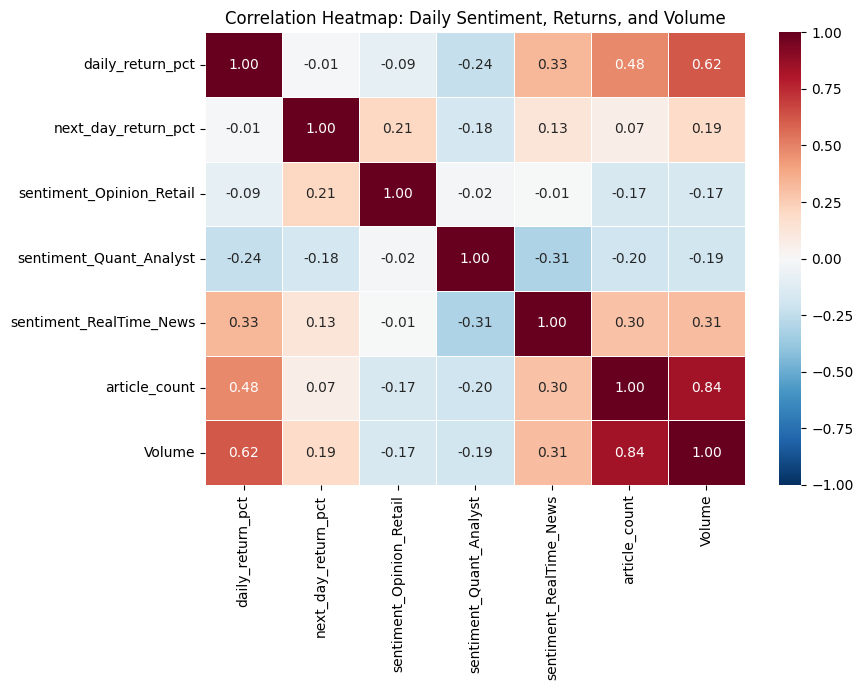

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

### CORRELATION HEATMAP
heatmap_cols = [
    'daily_return_pct', 'next_day_return_pct',
    'sentiment_Opinion_Retail', 'sentiment_Quant_Analyst', 'sentiment_RealTime_News',
    'article_count', 'Volume'
]
corr_matrix = daily[heatmap_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap: Daily Sentiment, Returns, and Volume')
plt.tight_layout()
plt.show()

**Description:**
The heatmap confirms what we saw in the Pearson analysis. RealTime_News sentiment has the strongest positive correlation with same-day returns (0.33), while Quant_Analyst shows a moderate negative one (−0.24). Opinion_Retail sentiment is weakly tied to same-day returns but has the highest positive link to next-day returns (0.21). We also noticed that article count and volume are strongly correlated with each other (0.84) and with same-day returns (0.48, 0.62), which suggests that high trading activity days also attract more news coverage, something to keep in mind as a possible confound. The three sentiment clusters are mostly uncorrelated with each other, meaning they capture somewhat independent signals.

### Multiple Linear Regression

Correlation only shows pairwise relationships, so it can't separate overlapping effects. A multiple linear regression lets us estimate each cluster's individual contribution to predicting returns while holding the others constant. We fit two OLS models:

- Model A (Same-Day): Does today's sentiment from each cluster predict today's stock return?
- Model B (Next-Day): Does today's sentiment predict tomorrow's return? (this is the real predictive test)

We used `statsmodels` OLS so we get nice summary statistics like R², F-test, p-values, and confidence intervals.

In [ ]:
import statsmodels.api as sm

predictors = ['sentiment_Opinion_Retail', 'sentiment_Quant_Analyst', 'sentiment_RealTime_News']

### MODEL A: SAME-DAY RETURNS
model_a_data = daily[predictors + ['daily_return_pct']].dropna()
X_a = sm.add_constant(model_a_data[predictors])
y_a = model_a_data['daily_return_pct']
model_a = sm.OLS(y_a, X_a).fit()

### MODEL B: NEXT-DAY RETURNS
model_b_data = daily[predictors + ['next_day_return_pct']].dropna()
X_b = sm.add_constant(model_b_data[predictors])
y_b = model_b_data['next_day_return_pct']
model_b = sm.OLS(y_b, X_b).fit()

# Compact model-level summary
model_overview = pd.DataFrame([
    {
        'Model': 'A (Same-Day)',
        'n': int(model_a.nobs),
        'R-squared': round(model_a.rsquared, 3),
        'Adj. R-squared': round(model_a.rsquared_adj, 3),
        'F-test p-value': round(model_a.f_pvalue, 4)
    },
    {
        'Model': 'B (Next-Day)',
        'n': int(model_b.nobs),
        'R-squared': round(model_b.rsquared, 3),
        'Adj. R-squared': round(model_b.rsquared_adj, 3),
        'F-test p-value': round(model_b.f_pvalue, 4)
    }
])

print('Regression Model Overview')
display(model_overview)

Regression Model Overview


,Model,n,R-squared,Adj. R-squared,F-test p-value
0,A (Same-Day),40,0.150,0.079,0.1148
1,B (Next-Day),40,0.077,0.000,0.4026


In [21]:
# Compact coefficient table for both models
coef_rows = []
for model_name, model in [('A (Same-Day)', model_a), ('B (Next-Day)', model_b)]:
    for pred in predictors:
        coef_rows.append({
            'Model': model_name,
            'Predictor': pred.replace('sentiment_', ''),
            'Coefficient (beta)': round(model.params[pred], 3),
            'p-value': round(model.pvalues[pred], 4)
        })

coef_table = pd.DataFrame(coef_rows)
print('Coefficient Summary')
display(coef_table)

Coefficient Summary


,Model,Predictor,Coefficient (beta),p-value
0,A (Same-Day),Opinion_Retail,-2.958,0.3903
1,A (Same-Day),Quant_Analyst,-4.073,0.3254
2,A (Same-Day),RealTime_News,5.534,0.0884
3,B (Next-Day),Opinion_Retail,4.367,0.2235
4,B (Next-Day),Quant_Analyst,-3.489,0.4153
5,B (Next-Day),RealTime_News,1.729,0.6007


**Description:**

For Model A (same-day), the three cluster sentiments together explain about 15% of the variance in same-day returns (R² = 0.150, Adj. R² = 0.079). The overall F-test isn't significant at α = 0.05 (p ≈ 0.115), which isn't super surprising given we only have about 40 trading days. RealTime_News has the largest positive coefficient (β ≈ +5.5, p ≈ 0.088), meaning a one-unit increase in real-time news sentiment is associated with about a 5.5 percentage-point increase in NVDA's same-day return. Opinion_Retail and Quant_Analyst both have negative coefficients for same-day returns, so when controlling for the other clusters they don't positively predict same-day movement.

For Model B (next-day), the model is weaker (R² = 0.077, Adj. R² ≈ 0, F p ≈ 0.40), meaning today's sentiment doesn't have much predictive power for tomorrow's return. Opinion_Retail has the largest positive coefficient (β ≈ +4.4), which goes along with the idea that opinion-driven sources might have a delayed effect, but it doesn't reach significance with our sample size.

The main takeaway is that RealTime_News is the strongest same-day predictor, which is consistent with the correlation analysis. The lack of strong next-day prediction suggests information gets priced in on the same day, which makes sense for a heavily traded stock like NVIDIA.

### Regression Coefficient Comparison

This chart compares the OLS regression coefficients (β) for each publisher cluster across both models. The error bars show 95% confidence intervals, if an error bar doesn't cross zero, that means the coefficient is significant at α = 0.05.

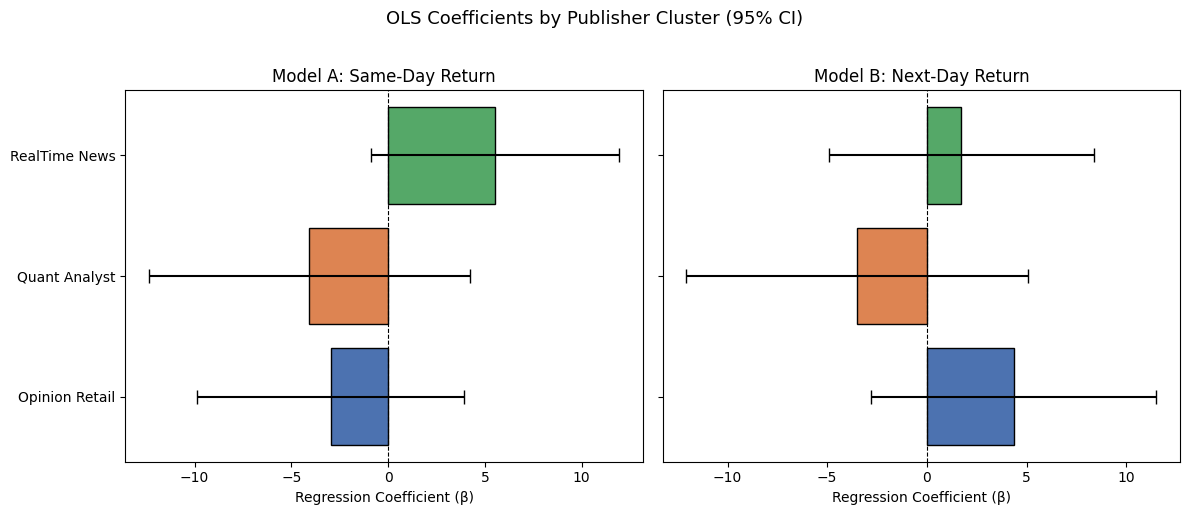

In [19]:
### COEFFICIENT COMPARISON CHART
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

cluster_labels = [p.replace('sentiment_', '').replace('_', ' ') for p in predictors]

for ax, model, title in [
    (axes[0], model_a, 'Model A: Same-Day Return'),
    (axes[1], model_b, 'Model B: Next-Day Return'),
]:
    coefs = [model.params[p] for p in predictors]
    ci = model.conf_int().loc[predictors]
    errors = [(coefs[i] - ci.iloc[i, 0], ci.iloc[i, 1] - coefs[i]) for i in range(len(predictors))]
    lower_err = [e[0] for e in errors]
    upper_err = [e[1] for e in errors]

    colors = ['#4c72b0', '#dd8452', '#55a868']
    ax.barh(cluster_labels, coefs, xerr=[lower_err, upper_err],
            color=colors, edgecolor='black', capsize=5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Regression Coefficient (β)')
    ax.set_title(title)

fig.suptitle('OLS Coefficients by Publisher Cluster (95% CI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Description:**
The chart backs up what we found in the numbers. For same-day returns (left panel), RealTime_News has the biggest positive coefficient and its confidence interval barely crosses zero, making it the most promising predictor of the three. Quant_Analyst and Opinion_Retail are both negative for same-day returns, though the wide confidence intervals show there's a lot of uncertainty because of the small sample. For next-day returns (right panel), Opinion_Retail flips to the most positive coefficient, which fits with the idea that opinion-based coverage might have a delayed influence, but again the wide confidence intervals mean we can't say for sure.

All three clusters' 95% CIs cross zero in both models, which makes sense given we only have about 40 observations and three predictors. We can't reject the null that any single cluster's coefficient is zero at the 5% level in the multivariate model (though RealTime_News came close in Model A at p ≈ 0.09). The bivariate Pearson correlation for RealTime_News was significant (p = 0.036), so when we look at it on its own, real-time news sentiment does have a detectable relationship with same-day returns, it's the multivariate setting that eats up the power.

## Ethics 
[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 > Yes there can be bias within the news sources, so we will need to cross-check information to ensure bias isn't involved
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 > The data we will use will not contain any personally identifiable information
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 > The data we used is from publicly available newspaper sources.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 > The sources we use do not contain any personal information of any person
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 > There might be some lesser known sources that are good predictions for the stock market for Nvidia
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 > They will be designed to represent how well each source can predict Nvidia Stock market
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
 > Yes we will record where we get our data

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 > Yes we will ensure that news sources are credible and don't have discriminatory variables
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 > Yes we will be able to explain how the model came to a conclusion based on the news sources it was fed
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 > We aren't anticipating users to be harmed by the results
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 > Yes our model will work one a single-run basis where we run it once to gather the results we need
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Conclusion & Discussion

In this project we set out to figure out which type of financial news source's sentiment best predicts NVIDIA's stock price movement during May–June 2023. We collected about 1,000 NVDA-related articles, grouped publishers into three clusters, Opinion/Retail (The Motley Fool, Seeking Alpha), Quant/Analyst (Zacks Investment Research), and RealTime News (MarketWatch, Benzinga, Investing.com), and scored each article using VADER sentiment analysis. After merging daily averaged sentiment with NVIDIA's daily stock returns, we ran Pearson correlations and OLS multiple linear regression to see how well each cluster predicts both same-day and next-day returns.

Our main finding is that RealTime News sentiment is the strongest same-day predictor of NVDA returns, with a statistically significant Pearson correlation (r = 0.33, p = 0.036) and the largest positive regression coefficient in our same-day model (β ≈ +5.5, p ≈ 0.09). Opinion/Retail and Quant/Analyst sentiment didn't show significant same-day associations. For next-day returns, no cluster reached statistical significance, though Opinion/Retail sentiment had a suggestive positive trend (r = 0.21, p ≈ 0.20). These results partially support our hypothesis, we expected that high-credibility, major sources would be stronger predictors, and RealTime News (which includes widely followed outlets like MarketWatch and Benzinga) did come out on top. However, we also hypothesized that next-day returns would show a stronger relationship, and that wasn't the case. This is consistent with efficient market theory for a heavily traded stock like NVIDIA, where information tends to get priced in fast. Our findings line up with prior work by Tetlock (2005) showing media sentiment influences stock prices, and with Gao et al. (2022) who found that sentiment from multiple providers can predict returns. The main thing our project adds is showing that different publisher types have different predictive power.

There are several limitations worth noting. First, the sample period is only two months (43 trading days), which really limits our statistical power, our regression models only had about 37 degrees of freedom with three predictors. Second, VADER was designed for social media text and isn't fine-tuned for financial language, so it might underestimate the true relationship between news tone and stock movement. Third, we can't establish causality here: the positive same-day correlation between RealTime News sentiment and returns could mean sentiment drives prices, or prices drive sentiment (journalists reacting to market moves), or both are driven by the same underlying events like earnings reports. Fourth, this period happened during NVIDIA's historic AI-driven rally, so our results might not generalize to other time periods or stocks. If we were to continue this work, we'd want to use a longer time window, try a finance-specific sentiment model like FinBERT, use intraday timestamps for more precise alignment, look at multiple tickers, and run Granger causality tests to better figure out the direction of the sentiment-price relationship.